# Fraud Detection in Credit Card Transactions

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [2]:
df.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [4]:
print(df.shape)
print(df.columns.tolist())

(284807, 31)
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [5]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(1081)

In [7]:
dup_mask = df.duplicated(keep=False)
dup_rows = df[dup_mask]

print("Class distribution among duplicate rows:")
print(dup_rows["Class"].value_counts())

Class distribution among duplicate rows:
Class
0    1822
1      32
Name: count, dtype: int64


In [8]:
extra_dup_rows = df[df.duplicated(keep="first")]

print("Class distribution among extra duplicate rows:")
print(extra_dup_rows["Class"].value_counts())

Class distribution among extra duplicate rows:
Class
0    1062
1      19
Name: count, dtype: int64


In [9]:
grouped = df.groupby(list(df.columns)).size()
duplicate_patterns = grouped[grouped > 1]

print("Number of distinct duplicate patterns:")
print(duplicate_patterns.shape[0])

Number of distinct duplicate patterns:
773


In [10]:
print("Extra duplicate rows:")
print(extra_dup_rows.shape[0])

Extra duplicate rows:
1081


In [11]:
print("Class distribution before duplicate removal:")
print(df["Class"].value_counts())

print("\nClass percentage before duplicate removal:")
print(df["Class"].value_counts(normalize=True) * 100)

Class distribution before duplicate removal:
Class
0    284315
1       492
Name: count, dtype: int64

Class percentage before duplicate removal:
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


In [12]:
df_no_duplicates = df.drop_duplicates()

print("Shape before duplicate removal:", df.shape)
print("Shape after duplicate removal:", df_no_duplicates.shape)

print("\nClass distribution after duplicate removal:")
print(df_no_duplicates["Class"].value_counts())

print("\nClass percentage after duplicate removal:")
print(df_no_duplicates["Class"].value_counts(normalize=True) * 100)

Shape before duplicate removal: (284807, 31)
Shape after duplicate removal: (283726, 31)

Class distribution after duplicate removal:
Class
0    283253
1       473
Name: count, dtype: int64

Class percentage after duplicate removal:
Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64


In [13]:
df_clean = df.drop_duplicates().copy()

print("Original dataset shape:", df.shape)
print("Cleaned dataset shape:", df_clean.shape)
print("Duplicates removed:", df.shape[0] - df_clean.shape[0])

Original dataset shape: (284807, 31)
Cleaned dataset shape: (283726, 31)
Duplicates removed: 1081


In [14]:
print("Remaining duplicate rows:", df_clean.duplicated().sum())

Remaining duplicate rows: 0


Count of each class:
Class
0    283253
1       473
Name: count, dtype: int64

Class 0 (Normal): 283,253 (99.83329%)
Class 1 (Fraud):  473 (0.16671%)


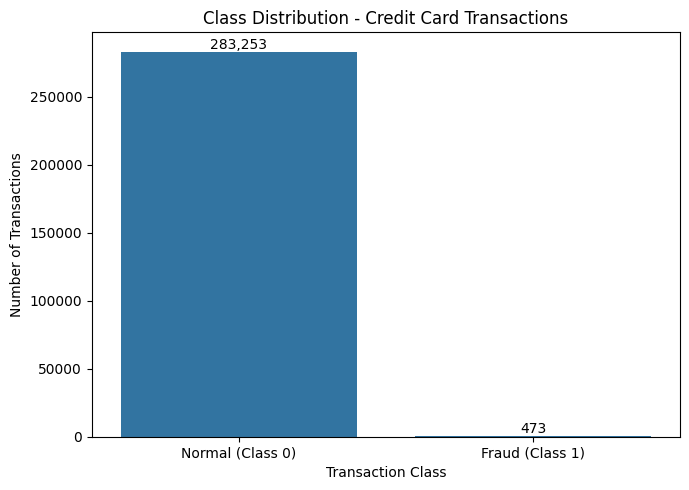

In [15]:
# Count of each class
class_counts = df_clean["Class"].value_counts().sort_index()

print("Count of each class:")
print(class_counts)

# Calculate percentages
total_rows = len(df_clean)

normal_pct = class_counts[0] / total_rows * 100
fraud_pct = class_counts[1] / total_rows * 100

print(f"\nClass 0 (Normal): {class_counts[0]:,} ({normal_pct:.5f}%)")
print(f"Class 1 (Fraud):  {class_counts[1]:,} ({fraud_pct:.5f}%)")

# Plot class distribution
plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df_clean,
    x="Class",
    order=[0, 1]
)

plt.title("Class Distribution - Credit Card Transactions")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")

plt.xticks(
    ticks=[0, 1],
    labels=["Normal (Class 0)", "Fraud (Class 1)"]
)

# Add count labels
for i, count in enumerate(class_counts):
    ax.text(
        i,
        count,
        f"{count:,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

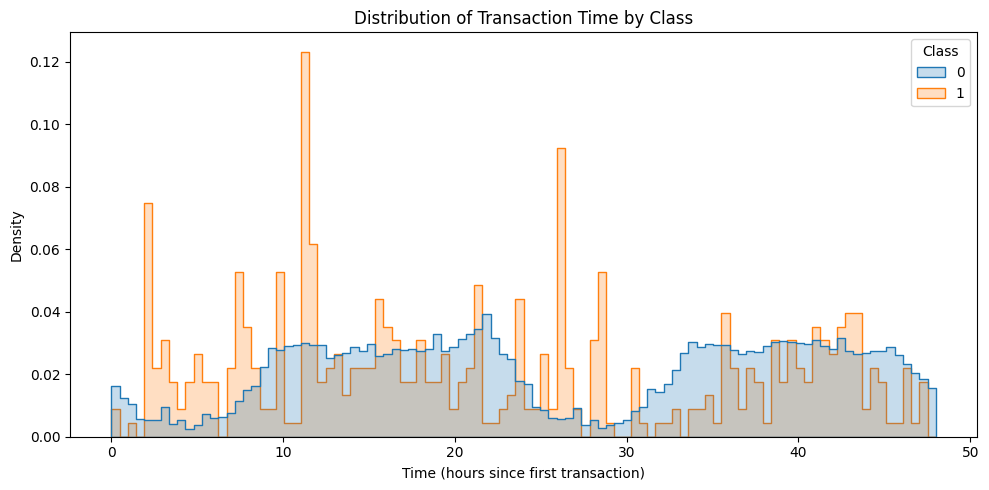

In [16]:
# --------------------------------------------------
# TIME ANALYSIS
# --------------------------------------------------

# Convert elapsed seconds to hours
time_hours = df_clean["Time"] / 3600

plot_df_time = pd.DataFrame({
    "Time_hours": time_hours,
    "Class": df_clean["Class"]
})

plt.figure(figsize=(10, 5))

sns.histplot(
    data=plot_df_time,
    x="Time_hours",
    hue="Class",
    bins=100,
    stat="density",
    common_norm=False,
    element="step",
    kde=False
)

plt.title("Distribution of Transaction Time by Class")
plt.xlabel("Time (hours since first transaction)")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

In [17]:
# --------------------------------------------------
# AMOUNT ANALYSIS
# --------------------------------------------------

print("Amount summary:")
print(df_clean["Amount"].describe())

print("\nNumber of zero-amount transactions:")
print((df_clean["Amount"] == 0).sum())

Amount summary:
count    283726.000000
mean         88.472687
std         250.399437
min           0.000000
25%           5.600000
50%          22.000000
75%          77.510000
max       25691.160000
Name: Amount, dtype: float64

Number of zero-amount transactions:
1808


In [18]:
# --------------------------------------------------
# AMOUNT DISTRIBUTION
# --------------------------------------------------

# Log transformation that safely handles Amount = 0
df_clean["Amount_log"] = np.log1p(df_clean["Amount"])

print("Amount_log summary:")
print(df_clean["Amount_log"].describe())

Amount_log summary:
count    283726.000000
mean          3.153760
std           1.657080
min           0.000000
25%           1.887070
50%           3.135494
75%           4.363226
max          10.153941
Name: Amount_log, dtype: float64


In [19]:
# Compare Amount between Normal and Fraud
amount_by_class = df_clean.groupby("Class")["Amount"].describe()

print("Amount statistics by class:")
print(amount_by_class)

Amount statistics by class:
          count        mean         std  min   25%    50%     75%       max
Class                                                                      
0      283253.0   88.413575  250.379023  0.0  5.67  22.00   77.46  25691.16
1         473.0  123.871860  260.211041  0.0  1.00   9.82  105.89   2125.87


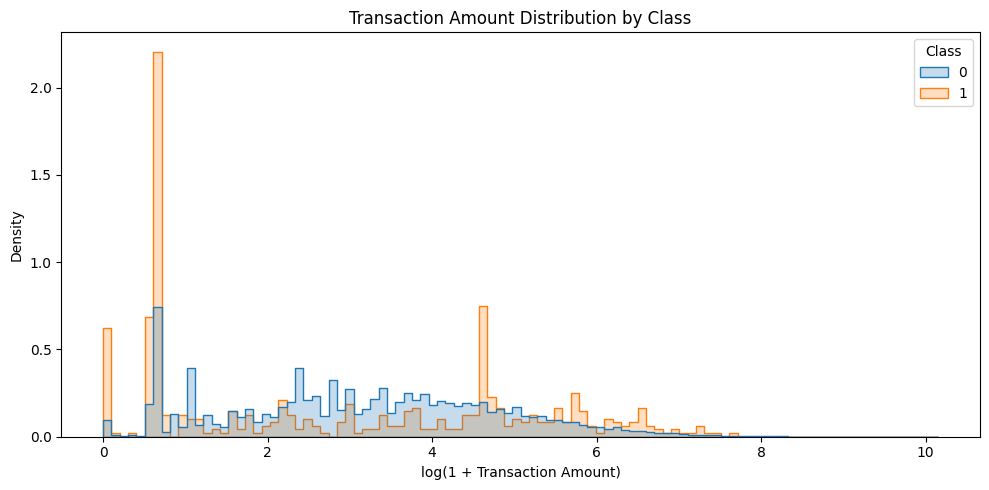

In [20]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df_clean,
    x="Amount_log",
    hue="Class",
    bins=100,
    stat="density",
    common_norm=False,
    element="step",
    kde=False
)

plt.title("Transaction Amount Distribution by Class")
plt.xlabel("log(1 + Transaction Amount)")
plt.ylabel("Density")

plt.tight_layout()
plt.show()

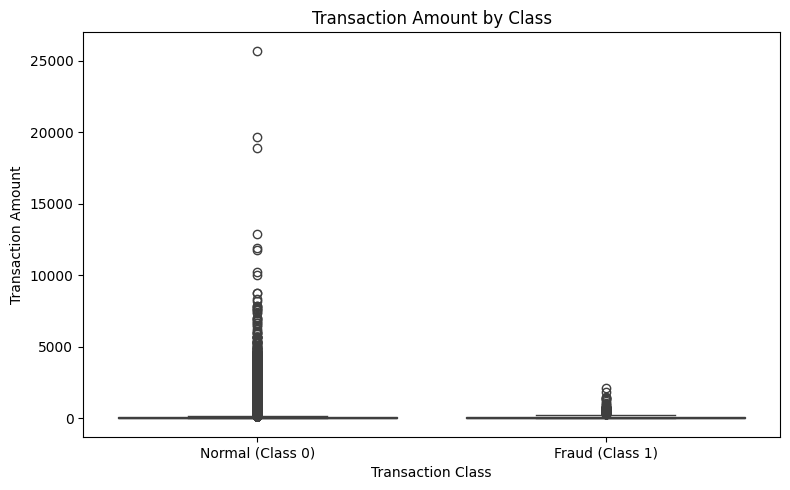

In [21]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="Class",
    y="Amount"
)

plt.title("Transaction Amount by Class")
plt.xlabel("Transaction Class")
plt.ylabel("Transaction Amount")

plt.xticks(
    [0, 1],
    ["Normal (Class 0)", "Fraud (Class 1)"]
)

plt.tight_layout()
plt.show()

In [22]:
# ============================================================
# EDA - V1 to V28 Feature Analysis
# ============================================================

# ------------------------------------------------------------
# A. Identify V1-V28 Features
# ------------------------------------------------------------

# Automatically identify the anonymized V1 to V28 columns
# from the cleaned dataset.
v_cols = [
    col for col in df_clean.columns
    if col.startswith("V")
    and col[1:].isdigit()
    and 1 <= int(col[1:]) <= 28
]

# Verify that all 28 V-features were identified
print(f"Found {len(v_cols)} V-features:")
print(v_cols)

Found 28 V-features:
['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28']


In [23]:
# ------------------------------------------------------------
# B. Compare Mean of V1-V28 by Class
# ------------------------------------------------------------

# Calculate the mean value of each V-feature separately
# for Normal transactions (Class 0) and Fraud transactions (Class 1).
mean_per_class = df_clean.groupby("Class")[v_cols].mean()

# Extract the mean values for each class separately
mean_class_0 = mean_per_class.loc[0]   # Normal transactions
mean_class_1 = mean_per_class.loc[1]   # Fraud transactions

# Display the mean values for both classes
print("Mean of V1-V28 for Normal transactions (Class 0):")
print(mean_class_0)

print("\nMean of V1-V28 for Fraud transactions (Class 1):")
print(mean_class_1)

Mean of V1-V28 for Normal transactions (Class 0):
V1     0.013439
V2    -0.009829
V3     0.012853
V4    -0.010440
V5     0.006769
V6     0.001251
V7     0.010447
V8    -0.002448
V9     0.002613
V10    0.007663
V11   -0.006004
V12    0.009476
V13    0.000762
V14    0.011668
V15    0.001166
V16    0.007845
V17    0.010963
V18    0.005120
V19   -0.001382
V20   -0.000489
V21   -0.001150
V22   -0.000160
V23    0.000360
V24    0.000393
V25   -0.000301
V26    0.000065
V27    0.001409
V28    0.000418
Name: 0, dtype: float64

Mean of V1-V28 for Fraud transactions (Class 1):
V1    -4.498280
V2     3.405965
V3    -6.729599
V4     4.472591
V5    -2.957197
V6    -1.432518
V7    -5.175912
V8     0.953255
V9    -2.522124
V10   -5.453274
V11    3.716347
V12   -6.103254
V13   -0.094324
V14   -6.835946
V15   -0.072830
V16   -4.000956
V17   -6.463285
V18   -2.157071
V19    0.669143
V20    0.405043
V21    0.466550
V22    0.086639
V23   -0.096464
V24   -0.106643
V25    0.040615
V26    0.050456
V27    0.213

In [24]:
# ------------------------------------------------------------
# C. Compare Median of V1-V28 by Class
# ------------------------------------------------------------

# Calculate the median value of each V-feature separately
# for Normal transactions (Class 0) and Fraud transactions (Class 1).
median_per_class = df_clean.groupby("Class")[v_cols].median()

# Extract the median values for each class separately
median_class_0 = median_per_class.loc[0]   # Normal transactions
median_class_1 = median_per_class.loc[1]   # Fraud transactions

# Display the median values for both classes
print("Median of V1-V28 for Normal transactions (Class 0):")
print(median_class_0)

print("\nMedian of V1-V28 for Fraud transactions (Class 1):")
print(median_class_1)

Median of V1-V28 for Normal transactions (Class 0):
V1     0.022562
V2     0.062561
V3     0.182247
V4    -0.024500
V5    -0.052807
V6    -0.274172
V7     0.041664
V8     0.021633
V9    -0.051368
V10   -0.092120
V11   -0.034446
V12    0.140573
V13   -0.012905
V14    0.051486
V15    0.049435
V16    0.068100
V17   -0.065096
V18   -0.001436
V19    0.002737
V20   -0.062507
V21   -0.029798
V22    0.006675
V23   -0.011077
V24    0.041115
V25    0.016190
V26   -0.052293
V27    0.001368
V28    0.011238
Name: 0, dtype: float64

Median of V1-V28 for Fraud transactions (Class 1):
V1    -2.271755
V2     2.617105
V3    -4.875397
V4     4.100098
V5    -1.372245
V6    -1.420468
V7    -2.902079
V8     0.617738
V9    -2.099049
V10   -4.466284
V11    3.525726
V12   -5.437354
V13   -0.063634
V14   -6.590550
V15   -0.038632
V16   -3.302899
V17   -5.157596
V18   -1.417917
V19    0.647709
V20    0.285559
V21    0.573898
V22    0.055179
V23   -0.075034
V24   -0.061263
V25    0.077913
V26    0.012792
V27    0

In [25]:
# ------------------------------------------------------------
# D. Mean Difference: Class 1 (Fraud) - Class 0 (Normal)
# ------------------------------------------------------------

# Calculate the difference between the fraud mean
# and the normal mean for every V-feature.
diff_mean = mean_class_1 - mean_class_0

# Display the signed mean difference for all V-features
print("Mean difference (Class 1 - Class 0):")
print(diff_mean)

Mean difference (Class 1 - Class 0):
V1    -4.511719
V2     3.415794
V3    -6.742452
V4     4.483031
V5    -2.963966
V6    -1.433769
V7    -5.186359
V8     0.955702
V9    -2.524737
V10   -5.460937
V11    3.722350
V12   -6.112730
V13   -0.095086
V14   -6.847614
V15   -0.073996
V16   -4.008801
V17   -6.474249
V18   -2.162191
V19    0.670525
V20    0.405532
V21    0.467701
V22    0.086798
V23   -0.096824
V24   -0.107036
V25    0.040916
V26    0.050391
V27    0.212365
V28    0.077853
dtype: float64


In [26]:
# ------------------------------------------------------------
# E. Rank V1-V28 by Absolute Mean Difference
# ------------------------------------------------------------

# Take the absolute value because we want to measure
# the magnitude of the difference, regardless of direction.
abs_diff = diff_mean.abs().sort_values(ascending=False)

# Select the top 10 V-features with the largest
# absolute difference between Fraud and Normal means.
top10_mean_diff_features = abs_diff.head(10).index.tolist()

# Display the ranking
print("Top 10 V-features by absolute mean difference:")
print(top10_mean_diff_features)

print("\nAbsolute mean difference values:")
print(abs_diff.head(10))

Top 10 V-features by absolute mean difference:
['V14', 'V3', 'V17', 'V12', 'V10', 'V7', 'V1', 'V4', 'V16', 'V11']

Absolute mean difference values:
V14    6.847614
V3     6.742452
V17    6.474249
V12    6.112730
V10    5.460937
V7     5.186359
V1     4.511719
V4     4.483031
V16    4.008801
V11    3.722350
dtype: float64


In [27]:
# ------------------------------------------------------------
# F. Correlation of V1-V28 Features with Target Class
# ------------------------------------------------------------

correlation_with_class = df_clean[v_cols + ["Class"]].corr()["Class"].drop("Class")

abs_correlation = correlation_with_class.abs().sort_values(ascending=False)

top10_correlation_features = abs_correlation.head(10).index.tolist()

print("Top 10 V-features by absolute correlation with Class:")
print(top10_correlation_features)

print("\nAbsolute correlation values:")
print(abs_correlation.head(10))

Top 10 V-features by absolute correlation with Class:
['V17', 'V14', 'V12', 'V10', 'V16', 'V3', 'V7', 'V11', 'V4', 'V18']

Absolute correlation values:
V17    0.313498
V14    0.293375
V12    0.250711
V10    0.206971
V16    0.187186
V3     0.182322
V7     0.172347
V11    0.149067
V4     0.129326
V18    0.105340
Name: Class, dtype: float64


In [28]:
# ------------------------------------------------------------
# F. Correlation of V1-V28 Features with Target Class
# ------------------------------------------------------------

correlation_with_class = df_clean[v_cols + ["Class"]].corr()["Class"].drop("Class")

abs_correlation = correlation_with_class.abs().sort_values(ascending=False)

top10_correlation_features = abs_correlation.head(10).index.tolist()

print("Top 10 V-features by absolute correlation with Class:")
print(top10_correlation_features)

print("\nAbsolute correlation values:")
print(abs_correlation.head(10))

Top 10 V-features by absolute correlation with Class:
['V17', 'V14', 'V12', 'V10', 'V16', 'V3', 'V7', 'V11', 'V4', 'V18']

Absolute correlation values:
V17    0.313498
V14    0.293375
V12    0.250711
V10    0.206971
V16    0.187186
V3     0.182322
V7     0.172347
V11    0.149067
V4     0.129326
V18    0.105340
Name: Class, dtype: float64


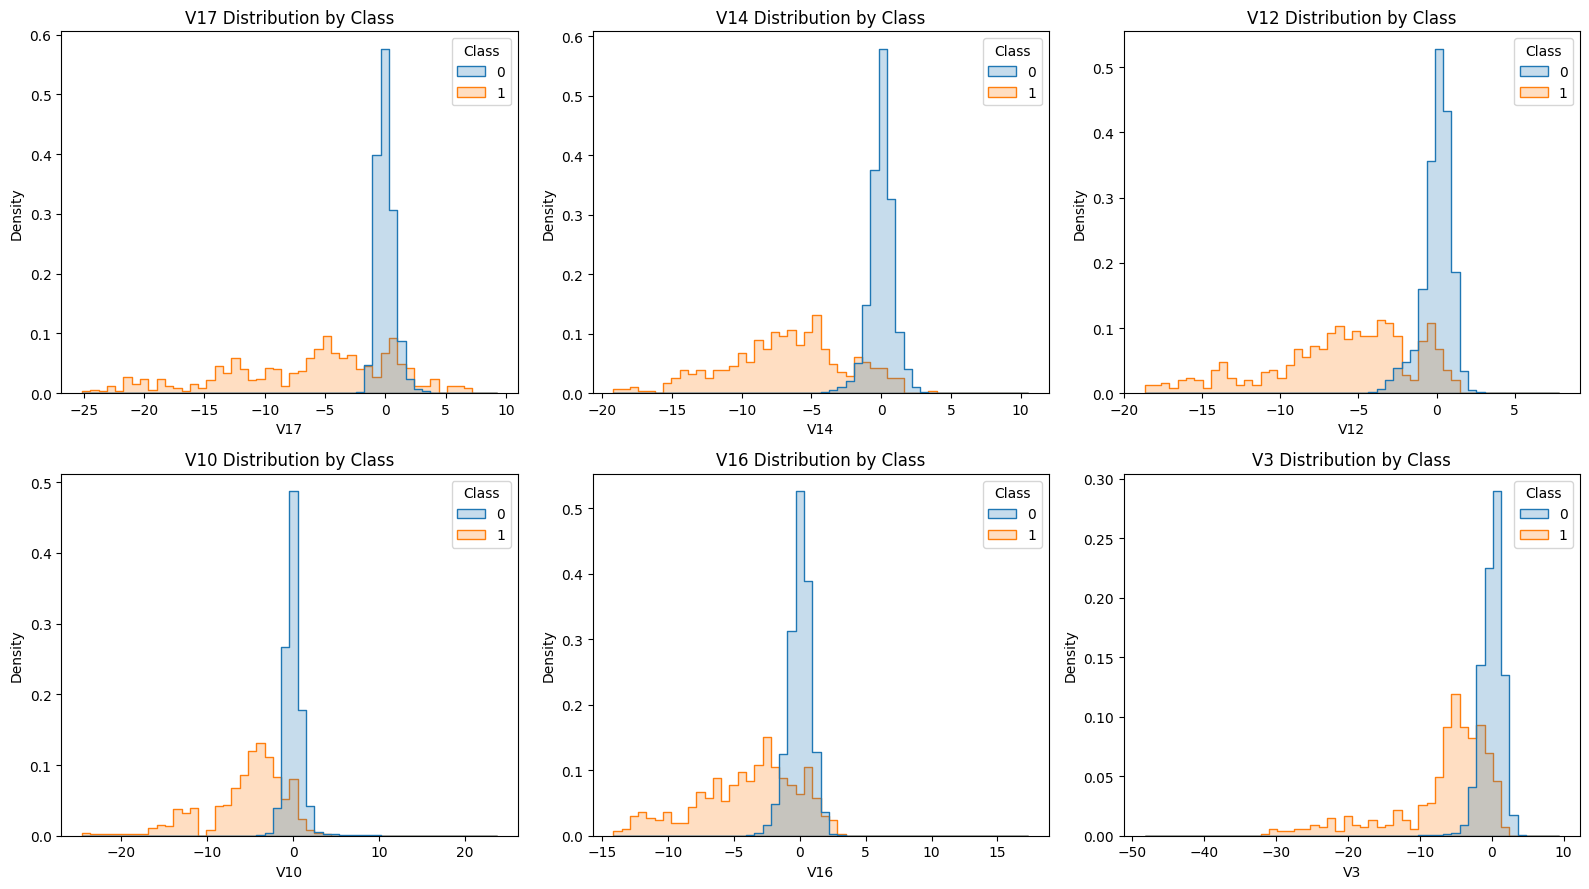

In [29]:
# ------------------------------------------------------------
# G. Distribution of Top V-Features by Class
# ------------------------------------------------------------

top_features = abs_correlation.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, feature in enumerate(top_features):
    sns.histplot(
        data=df_clean,
        x=feature,
        hue="Class",
        bins=50,
        stat="density",
        common_norm=False,
        element="step",
        kde=False,
        ax=axes[i]
    )
    
    axes[i].set_title(f"{feature} Distribution by Class")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Density")

plt.tight_layout()
plt.show()

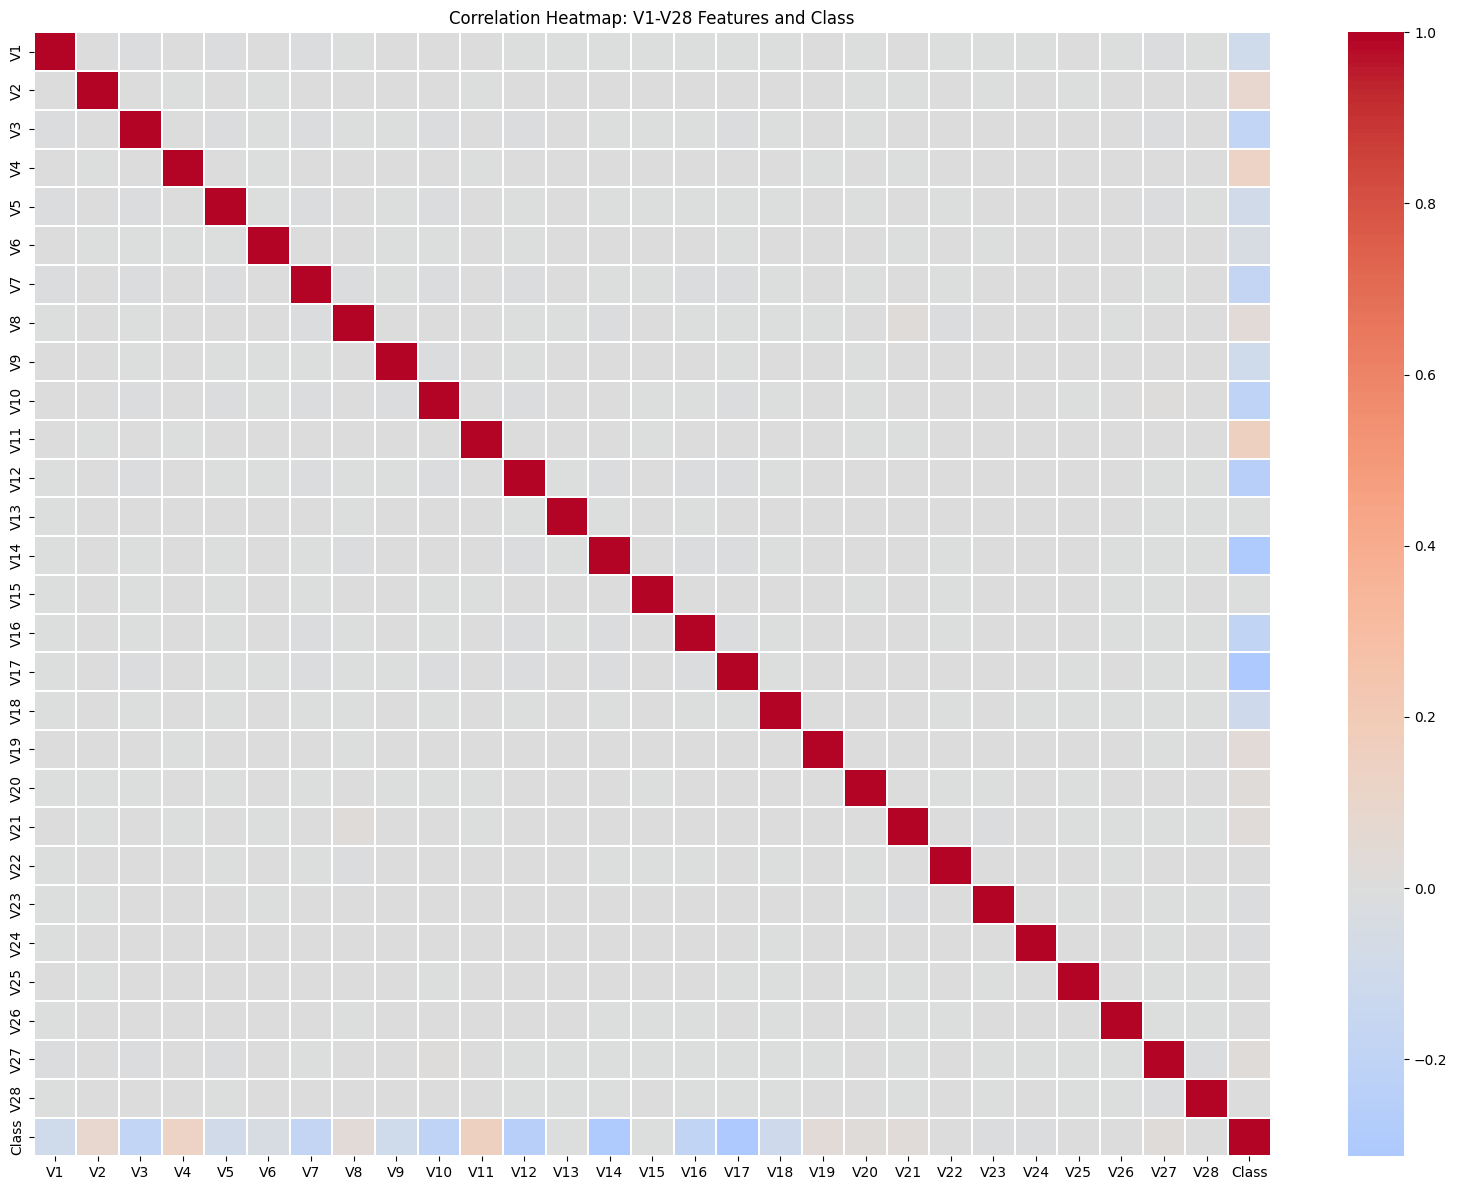

In [30]:
# ------------------------------------------------------------
# H. Correlation Heatmap of V1-V28 Features and Class
# ------------------------------------------------------------

corr_matrix = df_clean[v_cols + ["Class"]].corr()

plt.figure(figsize=(16, 12))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.2
)

plt.title("Correlation Heatmap: V1-V28 Features and Class")
plt.tight_layout()
plt.show()

In [31]:
# ============================================================
# PREPROCESSING & FEATURE PREPARATION
# ============================================================

# Prepare a separate dataset for machine learning
model_df = df_clean.copy()

# Remove EDA-only transformation
if "Amount_log" in model_df.columns:
    model_df = model_df.drop(columns=["Amount_log"])

# Verify dataset structure
print("Modeling dataset shape:", model_df.shape)

print("\nFeatures and target:")
print(model_df.columns.tolist())

print("\nTarget class distribution:")
print(model_df["Class"].value_counts())

Modeling dataset shape: (283726, 31)

Features and target:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Target class distribution:
Class
0    283253
1       473
Name: count, dtype: int64


In [32]:
# ============================================================
# TRAIN-TEST SPLIT
# ============================================================

# Separate features and target
X = model_df.drop(columns=["Class"])
y = model_df["Class"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

# Split data while preserving the class distribution
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining set:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTest set:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTest class distribution:")
print(y_test.value_counts())

Feature matrix shape: (283726, 30)
Target shape: (283726,)



Training set:
X_train: (226980, 30)
y_train: (226980,)

Test set:
X_test: (56746, 30)
y_test: (56746,)

Training class distribution:
Class
0    226602
1       378
Name: count, dtype: int64

Test class distribution:
Class
0    56651
1       95
Name: count, dtype: int64


In [33]:
# ============================================================
# FEATURE SCALING
# ============================================================

from sklearn.preprocessing import StandardScaler

# Create a scaler
scaler = StandardScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Apply the same transformation to test data
X_test_scaled = scaler.transform(X_test)

print("Scaled training data shape:", X_train_scaled.shape)
print("Scaled test data shape:", X_test_scaled.shape)

print("\nTraining data mean (first 5 features):")
print(X_train_scaled[:, :5].mean(axis=0))

print("\nTraining data standard deviation (first 5 features):")
print(X_train_scaled[:, :5].std(axis=0))

Scaled training data shape: (226980, 30)
Scaled test data shape: (56746, 30)

Training data mean (first 5 features):
[-1.52263630e-16  6.69909884e-18 -1.20208129e-17  8.51474245e-18
 -2.65459618e-17]

Training data standard deviation (first 5 features):
[1. 1. 1. 1. 1.]


In [34]:
# ============================================================
# CLASS IMBALANCE PREPARATION
# ============================================================

# Check the class distribution in the scaled training data
unique_classes, class_counts = np.unique(y_train, return_counts=True)

class_distribution = pd.DataFrame({
    "Class": unique_classes,
    "Count": class_counts,
    "Percentage": (class_counts / len(y_train)) * 100
})

print(class_distribution)

   Class   Count  Percentage
0      0  226602   99.833466
1      1     378    0.166534


In [35]:
# ============================================================
# CALCULATE CLASS WEIGHTS
# ============================================================

from sklearn.utils.class_weight import compute_class_weight

# Calculate balanced weights from the training target
classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

# Store weights in a dictionary
class_weight_dict = dict(zip(classes, class_weights))

print("Classes:", classes)
print("Class weights:", class_weights)
print("Class weight dictionary:", class_weight_dict)

Classes: [0 1]
Class weights: [  0.50083406 300.23809524]
Class weight dictionary: {np.int64(0): np.float64(0.5008340614822464), np.int64(1): np.float64(300.23809523809524)}


In [36]:
# ============================================================
# LOGISTIC REGRESSION — BASELINE MODEL
# ============================================================

from sklearn.linear_model import LogisticRegression

# Create the Logistic Regression model
logistic_model = LogisticRegression(
    class_weight=class_weight_dict,
    max_iter=1000,
    random_state=42
)

# Train the model
logistic_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [37]:
# ============================================================
# LOGISTIC REGRESSION — TEST PREDICTIONS
# ============================================================

# Predict the class labels using the default threshold of 0.5
y_pred = logistic_model.predict(X_test_scaled)

# Predict the probability of the Fraud class (Class 1)
y_prob = logistic_model.predict_proba(X_test_scaled)[:, 1]

print("Predicted class labels shape:", y_pred.shape)
print("Predicted probability shape:", y_prob.shape)

print("\nFirst 10 predicted labels:")
print(y_pred[:10])

print("\nFirst 10 fraud probabilities:")
print(y_prob[:10])

Predicted class labels shape: (56746,)
Predicted probability shape: (56746,)

First 10 predicted labels:
[0 0 0 0 0 0 0 0 0 0]

First 10 fraud probabilities:
[0.02162645 0.02007152 0.01024023 0.01572015 0.21923533 0.06080725
 0.02212544 0.03847994 0.08682055 0.00180108]


In [38]:
# ============================================================
# LOGISTIC REGRESSION — BASELINE EVALUATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score
)

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))

# ROC-AUC
roc_auc = roc_auc_score(y_test, y_prob)

# PR-AUC / Average Precision
pr_auc = average_precision_score(y_test, y_prob)

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC: {pr_auc:.4f}")

Confusion Matrix:
[[55262  1389]
 [   12    83]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9998    0.9755    0.9875     56651
           1     0.0564    0.8737    0.1059        95

    accuracy                         0.9753     56746
   macro avg     0.5281    0.9246    0.5467     56746
weighted avg     0.9982    0.9753    0.9860     56746

ROC-AUC: 0.9657
PR-AUC: 0.6719


In [39]:
# ============================================================
# CREATE VALIDATION SET FOR THRESHOLD SELECTION
# ============================================================

# Split the training data into training and validation sets
X_train_model, X_val, y_train_model, y_val = train_test_split(
    X_train_scaled,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

print("Model training set:", X_train_model.shape)
print("Validation set:", X_val.shape)

print("\nModel training class distribution:")
print(y_train_model.value_counts())

print("\nValidation class distribution:")
print(y_val.value_counts())

Model training set: (181584, 30)
Validation set: (45396, 30)

Model training class distribution:
Class
0    181282
1       302
Name: count, dtype: int64

Validation class distribution:
Class
0    45320
1       76
Name: count, dtype: int64


In [40]:
# ============================================================
# LOGISTIC REGRESSION — VALIDATION MODEL
# ============================================================

# Create a Logistic Regression model for the validation workflow
logistic_model_val = LogisticRegression(
    class_weight=class_weight_dict,
    max_iter=1000,
    random_state=42
)

# Train only on the model-training subset
logistic_model_val.fit(X_train_model, y_train_model)

print("Validation workflow model trained successfully.")

Validation workflow model trained successfully.


In [41]:
# ============================================================
# LOGISTIC REGRESSION — VALIDATION EVALUATION
# ============================================================

# Generate predictions on the validation set
y_val_pred = logistic_model_val.predict(X_val)
y_val_prob = logistic_model_val.predict_proba(X_val)[:, 1]

# Confusion matrix
val_cm = confusion_matrix(y_val, y_val_pred)

print("Validation Confusion Matrix:")
print(val_cm)

print("\nValidation Classification Report:")
print(classification_report(y_val, y_val_pred, digits=4))

# ROC-AUC
val_roc_auc = roc_auc_score(y_val, y_val_prob)

# PR-AUC
val_pr_auc = average_precision_score(y_val, y_val_prob)

print(f"Validation ROC-AUC: {val_roc_auc:.4f}")
print(f"Validation PR-AUC:  {val_pr_auc:.4f}")

Validation Confusion Matrix:
[[44141  1179]
 [    8    68]]

Validation Classification Report:
              precision    recall  f1-score   support

           0     0.9998    0.9740    0.9867     45320
           1     0.0545    0.8947    0.1028        76

    accuracy                         0.9739     45396
   macro avg     0.5272    0.9344    0.5448     45396
weighted avg     0.9982    0.9739    0.9853     45396

Validation ROC-AUC: 0.9749
Validation PR-AUC:  0.8142


In [42]:
# ============================================================
# THRESHOLD TUNING — VALIDATION SET
# ============================================================

from sklearn.metrics import precision_score, recall_score, f1_score

threshold_results = []

# Evaluate a range of probability thresholds
thresholds = np.arange(0.10, 1.00, 0.01)

for threshold in thresholds:
    y_val_threshold_pred = (y_val_prob >= threshold).astype(int)

    precision = precision_score(y_val, y_val_threshold_pred, zero_division=0)
    recall = recall_score(y_val, y_val_threshold_pred, zero_division=0)
    f1 = f1_score(y_val, y_val_threshold_pred, zero_division=0)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

threshold_df = pd.DataFrame(threshold_results)

# Find the threshold with the highest validation F1-score
best_threshold_row = threshold_df.loc[threshold_df["F1"].idxmax()]

print("Best Validation Threshold:")
print(f"Threshold: {best_threshold_row['Threshold']:.2f}")
print(f"Precision: {best_threshold_row['Precision']:.4f}")
print(f"Recall: {best_threshold_row['Recall']:.4f}")
print(f"F1-score: {best_threshold_row['F1']:.4f}")

Best Validation Threshold:
Threshold: 0.99
Precision: 0.5752
Recall: 0.8553
F1-score: 0.6878


In [43]:
# ============================================================
# FINAL TEST EVALUATION — SELECTED VALIDATION THRESHOLD
# ============================================================

# Use the threshold selected from the validation set
selected_threshold = best_threshold_row["Threshold"]

# Generate probability predictions on the untouched test set
y_test_prob = logistic_model_val.predict_proba(X_test_scaled)[:, 1]

# Convert probabilities into class predictions
y_test_pred_tuned = (y_test_prob >= selected_threshold).astype(int)

# Confusion matrix
test_cm_tuned = confusion_matrix(y_test, y_test_pred_tuned)

print(f"Selected Threshold: {selected_threshold:.2f}")
print("\nFinal Test Confusion Matrix:")
print(test_cm_tuned)

print("\nFinal Test Classification Report:")
print(classification_report(y_test, y_test_pred_tuned, digits=4))

# Threshold-independent metrics
test_roc_auc = roc_auc_score(y_test, y_test_prob)
test_pr_auc = average_precision_score(y_test, y_test_prob)

print(f"Final Test ROC-AUC: {test_roc_auc:.4f}")
print(f"Final Test PR-AUC:  {test_pr_auc:.4f}")

Selected Threshold: 0.99

Final Test Confusion Matrix:
[[56606    45]
 [   20    75]]

Final Test Classification Report:
              precision    recall  f1-score   support

           0     0.9996    0.9992    0.9994     56651
           1     0.6250    0.7895    0.6977        95

    accuracy                         0.9989     56746
   macro avg     0.8123    0.8943    0.8486     56746
weighted avg     0.9990    0.9989    0.9989     56746

Final Test ROC-AUC: 0.9617
Final Test PR-AUC:  0.6886


In [44]:
# ============================================================
# RANDOM FOREST — MODEL TRAINING
# ============================================================

from sklearn.ensemble import RandomForestClassifier

# Create the Random Forest model
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Train only on the model-training subset
random_forest_model.fit(X_train_model, y_train_model)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [45]:
# ============================================================
# RANDOM FOREST — VALIDATION PREDICTIONS
# ============================================================

# Generate predictions on the validation set
y_val_rf_pred = random_forest_model.predict(X_val)

# Generate fraud probabilities
y_val_rf_prob = random_forest_model.predict_proba(X_val)[:, 1]

print("Validation predictions generated successfully.")
print(f"Prediction shape: {y_val_rf_pred.shape}")
print(f"Probability shape: {y_val_rf_prob.shape}")

Validation predictions generated successfully.
Prediction shape: (45396,)
Probability shape: (45396,)


In [46]:
# ============================================================
# RANDOM FOREST — VALIDATION EVALUATION
# ============================================================

# Confusion matrix
rf_val_cm = confusion_matrix(y_val, y_val_rf_pred)

print("Random Forest Validation Confusion Matrix:")
print(rf_val_cm)

print("\nRandom Forest Validation Classification Report:")
print(classification_report(y_val, y_val_rf_pred, digits=4))

# Threshold-independent metrics
rf_val_roc_auc = roc_auc_score(y_val, y_val_rf_prob)
rf_val_pr_auc = average_precision_score(y_val, y_val_rf_prob)

print(f"Random Forest Validation ROC-AUC: {rf_val_roc_auc:.4f}")
print(f"Random Forest Validation PR-AUC:  {rf_val_pr_auc:.4f}")

Random Forest Validation Confusion Matrix:
[[45317     3]
 [   11    65]]

Random Forest Validation Classification Report:
              precision    recall  f1-score   support

           0     0.9998    0.9999    0.9998     45320
           1     0.9559    0.8553    0.9028        76

    accuracy                         0.9997     45396
   macro avg     0.9778    0.9276    0.9513     45396
weighted avg     0.9997    0.9997    0.9997     45396

Random Forest Validation ROC-AUC: 0.9451
Random Forest Validation PR-AUC:  0.8699


In [47]:
# ============================================================
# RANDOM FOREST — VALIDATION THRESHOLD TUNING
# ============================================================

rf_threshold_results = []

thresholds = np.arange(0.10, 1.00, 0.01)

for threshold in thresholds:
    y_val_rf_threshold_pred = (
        y_val_rf_prob >= threshold
    ).astype(int)

    precision = precision_score(
        y_val,
        y_val_rf_threshold_pred,
        zero_division=0
    )

    recall = recall_score(
        y_val,
        y_val_rf_threshold_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        y_val_rf_threshold_pred,
        zero_division=0
    )

    rf_threshold_results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

rf_threshold_df = pd.DataFrame(rf_threshold_results)

# Find the threshold with the highest validation F1-score
best_rf_threshold_row = rf_threshold_df.loc[
    rf_threshold_df["F1"].idxmax()
]

print("Best Random Forest Validation Threshold:")
print(f"Threshold: {best_rf_threshold_row['Threshold']:.2f}")
print(f"Precision: {best_rf_threshold_row['Precision']:.4f}")
print(f"Recall: {best_rf_threshold_row['Recall']:.4f}")
print(f"F1-score: {best_rf_threshold_row['F1']:.4f}")

Best Random Forest Validation Threshold:
Threshold: 0.38
Precision: 0.9559
Recall: 0.8553
F1-score: 0.9028


In [48]:
# ============================================================
# FINAL TEST EVALUATION — RANDOM FOREST
# ============================================================

# Use the threshold selected from the validation set
selected_rf_threshold = best_rf_threshold_row["Threshold"]

# Generate fraud probabilities on the untouched test set
y_test_rf_prob = random_forest_model.predict_proba(X_test_scaled)[:, 1]

# Apply the validation-selected threshold
y_test_rf_pred_tuned = (
    y_test_rf_prob >= selected_rf_threshold
).astype(int)

# Confusion matrix
rf_test_cm = confusion_matrix(
    y_test,
    y_test_rf_pred_tuned
)

print(f"Selected Random Forest Threshold: {selected_rf_threshold:.2f}")

print("\nFinal Random Forest Test Confusion Matrix:")
print(rf_test_cm)

print("\nFinal Random Forest Test Classification Report:")
print(
    classification_report(
        y_test,
        y_test_rf_pred_tuned,
        digits=4
    )
)

# Threshold-independent metrics
rf_test_roc_auc = roc_auc_score(
    y_test,
    y_test_rf_prob
)

rf_test_pr_auc = average_precision_score(
    y_test,
    y_test_rf_prob
)

print(f"Final Random Forest Test ROC-AUC: {rf_test_roc_auc:.4f}")
print(f"Final Random Forest Test PR-AUC:  {rf_test_pr_auc:.4f}")

Selected Random Forest Threshold: 0.38

Final Random Forest Test Confusion Matrix:
[[56645     6]
 [   23    72]]

Final Random Forest Test Classification Report:
              precision    recall  f1-score   support

           0     0.9996    0.9999    0.9997     56651
           1     0.9231    0.7579    0.8324        95

    accuracy                         0.9995     56746
   macro avg     0.9613    0.8789    0.9161     56746
weighted avg     0.9995    0.9995    0.9995     56746

Final Random Forest Test ROC-AUC: 0.9497
Final Random Forest Test PR-AUC:  0.8133


In [49]:
# ============================================================
# XGBOOST — MODEL TRAINING
# ============================================================

import xgboost as xgb
from xgboost import XGBClassifier

# Calculate the class imbalance ratio from the model-training data
negative_count = (y_train_model == 0).sum()
positive_count = (y_train_model == 1).sum()

scale_pos_weight = negative_count / positive_count

print(f"Negative samples: {negative_count}")
print(f"Positive samples: {positive_count}")
print(f"scale_pos_weight: {scale_pos_weight:.4f}")

# Create the XGBoost model
xgboost_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

# Train only on the model-training subset
xgboost_model.fit(
    X_train_model,
    y_train_model
)

print("\nXGBoost model trained successfully.")

Negative samples: 181282
Positive samples: 302
scale_pos_weight: 600.2715



XGBoost model trained successfully.


In [50]:
# ============================================================
# XGBOOST — VALIDATION PREDICTIONS
# ============================================================

# Generate class predictions on the validation set
y_val_xgb_pred = xgboost_model.predict(X_val)

# Generate fraud probabilities
y_val_xgb_prob = xgboost_model.predict_proba(X_val)[:, 1]

print("XGBoost validation predictions generated successfully.")
print(f"Prediction shape: {y_val_xgb_pred.shape}")
print(f"Probability shape: {y_val_xgb_prob.shape}")

XGBoost validation predictions generated successfully.
Prediction shape: (45396,)
Probability shape: (45396,)


In [51]:
# ============================================================
# XGBOOST — VALIDATION EVALUATION
# ============================================================

# Confusion matrix
xgb_val_cm = confusion_matrix(
    y_val,
    y_val_xgb_pred
)

print("XGBoost Validation Confusion Matrix:")
print(xgb_val_cm)

print("\nXGBoost Validation Classification Report:")
print(
    classification_report(
        y_val,
        y_val_xgb_pred,
        digits=4
    )
)

# Threshold-independent metrics
xgb_val_roc_auc = roc_auc_score(
    y_val,
    y_val_xgb_prob
)

xgb_val_pr_auc = average_precision_score(
    y_val,
    y_val_xgb_prob
)

print(f"XGBoost Validation ROC-AUC: {xgb_val_roc_auc:.4f}")
print(f"XGBoost Validation PR-AUC:  {xgb_val_pr_auc:.4f}")

XGBoost Validation Confusion Matrix:
[[45316     4]
 [   11    65]]

XGBoost Validation Classification Report:
              precision    recall  f1-score   support

           0     0.9998    0.9999    0.9998     45320
           1     0.9420    0.8553    0.8966        76

    accuracy                         0.9997     45396
   macro avg     0.9709    0.9276    0.9482     45396
weighted avg     0.9997    0.9997    0.9997     45396

XGBoost Validation ROC-AUC: 0.9751
XGBoost Validation PR-AUC:  0.8801


In [52]:
# ============================================================
# XGBOOST — VALIDATION THRESHOLD TUNING
# ============================================================

xgb_threshold_results = []

thresholds = np.arange(0.10, 1.00, 0.01)

for threshold in thresholds:
    y_val_xgb_threshold_pred = (
        y_val_xgb_prob >= threshold
    ).astype(int)

    precision = precision_score(
        y_val,
        y_val_xgb_threshold_pred,
        zero_division=0
    )

    recall = recall_score(
        y_val,
        y_val_xgb_threshold_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        y_val_xgb_threshold_pred,
        zero_division=0
    )

    xgb_threshold_results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

xgb_threshold_df = pd.DataFrame(xgb_threshold_results)

# Find the threshold with the highest validation F1-score
best_xgb_threshold_row = xgb_threshold_df.loc[
    xgb_threshold_df["F1"].idxmax()
]

print("Best XGBoost Validation Threshold:")
print(f"Threshold: {best_xgb_threshold_row['Threshold']:.2f}")
print(f"Precision: {best_xgb_threshold_row['Precision']:.4f}")
print(f"Recall: {best_xgb_threshold_row['Recall']:.4f}")
print(f"F1-score: {best_xgb_threshold_row['F1']:.4f}")

Best XGBoost Validation Threshold:
Threshold: 0.79
Precision: 0.9701
Recall: 0.8553
F1-score: 0.9091


In [53]:
# ============================================================
# FINAL TEST EVALUATION — XGBOOST
# ============================================================

# Use the threshold selected from the validation set
selected_xgb_threshold = best_xgb_threshold_row["Threshold"]

# Generate fraud probabilities on the untouched test set
y_test_xgb_prob = xgboost_model.predict_proba(X_test_scaled)[:, 1]

# Apply the validation-selected threshold
y_test_xgb_pred_tuned = (
    y_test_xgb_prob >= selected_xgb_threshold
).astype(int)

# Confusion matrix
xgb_test_cm = confusion_matrix(
    y_test,
    y_test_xgb_pred_tuned
)

print(f"Selected XGBoost Threshold: {selected_xgb_threshold:.2f}")

print("\nFinal XGBoost Test Confusion Matrix:")
print(xgb_test_cm)

print("\nFinal XGBoost Test Classification Report:")
print(
    classification_report(
        y_test,
        y_test_xgb_pred_tuned,
        digits=4
    )
)

# Threshold-independent metrics
xgb_test_roc_auc = roc_auc_score(
    y_test,
    y_test_xgb_prob
)

xgb_test_pr_auc = average_precision_score(
    y_test,
    y_test_xgb_prob
)

print(f"Final XGBoost Test ROC-AUC: {xgb_test_roc_auc:.4f}")
print(f"Final XGBoost Test PR-AUC:  {xgb_test_pr_auc:.4f}")

Selected XGBoost Threshold: 0.79

Final XGBoost Test Confusion Matrix:
[[56649     2]
 [   24    71]]

Final XGBoost Test Classification Report:
              precision    recall  f1-score   support

           0     0.9996    1.0000    0.9998     56651
           1     0.9726    0.7474    0.8452        95

    accuracy                         0.9995     56746
   macro avg     0.9861    0.8737    0.9225     56746
weighted avg     0.9995    0.9995    0.9995     56746



Final XGBoost Test ROC-AUC: 0.9707
Final XGBoost Test PR-AUC:  0.8153


In [54]:
# ============================================================
# MODEL COMPARISON — FINAL TEST RESULTS
# ============================================================

# Store final predictions and probabilities for all models
final_model_results = [
    {
        "Model": "Logistic Regression",
        "Threshold": selected_threshold,
        "Predictions": y_test_pred_tuned,
        "Probabilities": y_test_prob
    },
    {
        "Model": "Random Forest",
        "Threshold": selected_rf_threshold,
        "Predictions": y_test_rf_pred_tuned,
        "Probabilities": y_test_rf_prob
    },
    {
        "Model": "XGBoost",
        "Threshold": selected_xgb_threshold,
        "Predictions": y_test_xgb_pred_tuned,
        "Probabilities": y_test_xgb_prob
    }
]

# Calculate final test metrics automatically
comparison_rows = []

for result in final_model_results:

    y_pred = result["Predictions"]
    y_prob = result["Probabilities"]

    comparison_rows.append({
        "Model": result["Model"],
        "Threshold": result["Threshold"],
        "Accuracy": accuracy_score(y_test, y_pred),
        "Fraud Precision": precision_score(
            y_test, y_pred, zero_division=0
        ),
        "Fraud Recall": recall_score(
            y_test, y_pred, zero_division=0
        ),
        "Fraud F1": f1_score(
            y_test, y_pred, zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_test, y_prob
        ),
        "PR-AUC": average_precision_score(
            y_test, y_prob
        )
    })

# Create comparison DataFrame
model_comparison = pd.DataFrame(comparison_rows)

# Round numerical values for clean presentation
model_comparison = model_comparison.round(4)

# Display the comparison table without the DataFrame index
model_comparison.style.hide(axis="index")

Model,Threshold,Accuracy,Fraud Precision,Fraud Recall,Fraud F1,ROC-AUC,PR-AUC
Logistic Regression,0.990000,0.998900,0.625000,0.789500,0.697700,0.961700,0.688600
Random Forest,0.380000,0.999500,0.923100,0.757900,0.832400,0.949700,0.813300
XGBoost,0.790000,0.999500,0.972600,0.747400,0.845200,0.970700,0.815300


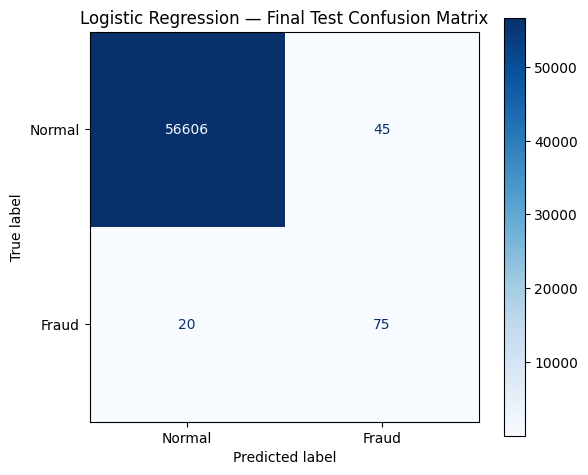

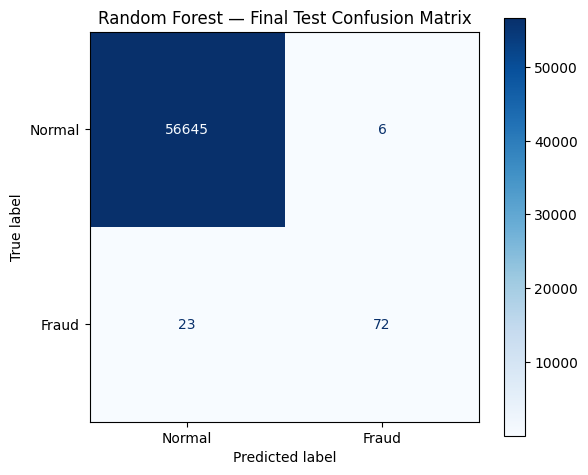

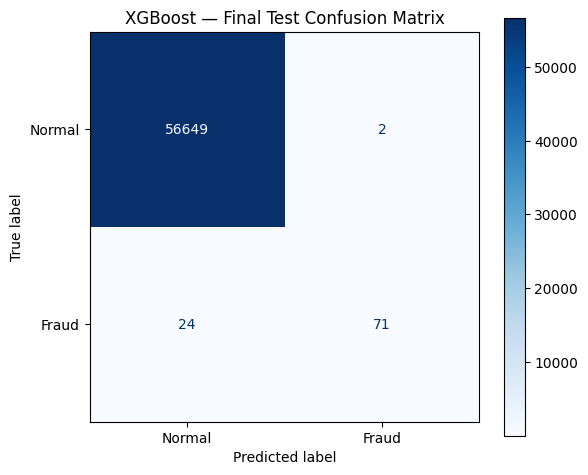

In [55]:
# ============================================================
# CONFUSION MATRIX COMPARISON — FINAL TEST SET
# ============================================================

from sklearn.metrics import ConfusionMatrixDisplay

# Store final predictions for each model
final_predictions = {
    "Logistic Regression": y_test_pred_tuned,
    "Random Forest": y_test_rf_pred_tuned,
    "XGBoost": y_test_xgb_pred_tuned
}

# Plot one confusion matrix for each model
for model_name, predictions in final_predictions.items():

    fig, ax = plt.subplots(figsize=(6, 5))

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        predictions,
        display_labels=["Normal", "Fraud"],
        cmap="Blues",
        values_format="d",
        ax=ax
    )

    ax.set_title(f"{model_name} — Final Test Confusion Matrix")

    plt.tight_layout()
    plt.show()

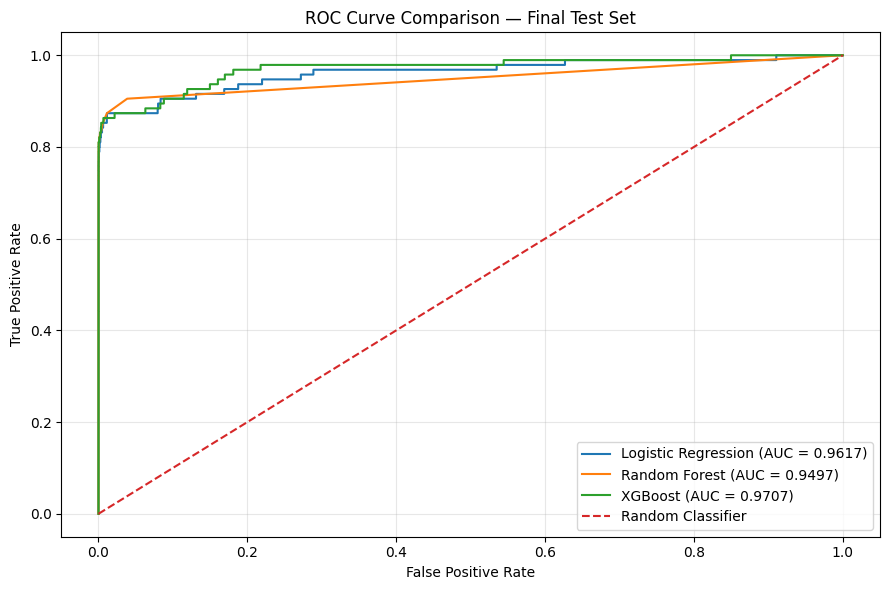

In [56]:
# ============================================================
# ROC CURVE COMPARISON — FINAL TEST SET
# ============================================================

from sklearn.metrics import roc_curve, auc

# Calculate ROC curve values for each model
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_test_prob)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_test_rf_prob)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_test_xgb_prob)

# Calculate AUC values
auc_lr = auc(fpr_lr, tpr_lr)
auc_rf = auc(fpr_rf, tpr_rf)
auc_xgb = auc(fpr_xgb, tpr_xgb)

# Plot ROC curves
plt.figure(figsize=(9, 6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f"Logistic Regression (AUC = {auc_lr:.4f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {auc_rf:.4f})"
)

plt.plot(
    fpr_xgb,
    tpr_xgb,
    label=f"XGBoost (AUC = {auc_xgb:.4f})"
)

# Random classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("ROC Curve Comparison — Final Test Set")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

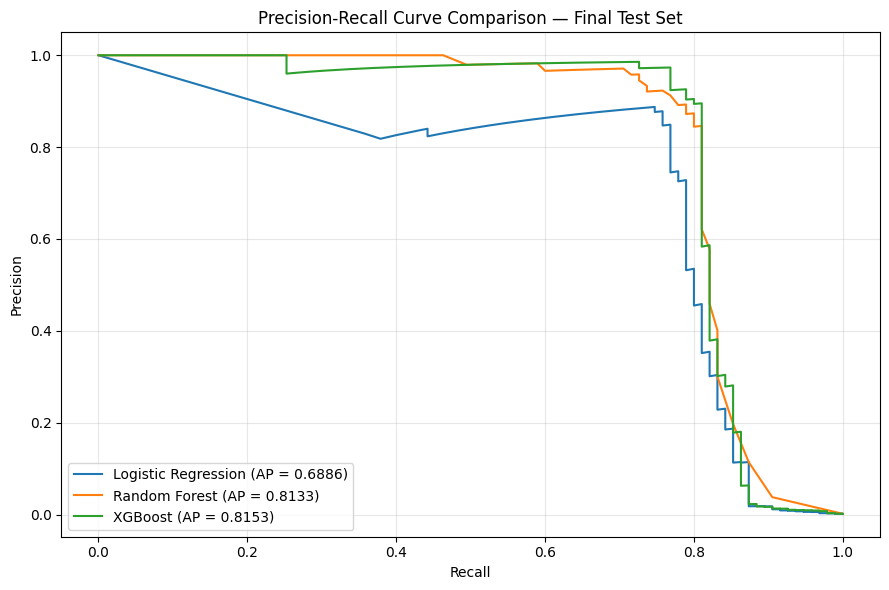

In [57]:
# ============================================================
# PRECISION-RECALL CURVE COMPARISON — FINAL TEST SET
# ============================================================

from sklearn.metrics import precision_recall_curve

# Calculate Precision-Recall values for each model
precision_lr, recall_lr, _ = precision_recall_curve(
    y_test,
    y_test_prob
)

precision_rf, recall_rf, _ = precision_recall_curve(
    y_test,
    y_test_rf_prob
)

precision_xgb, recall_xgb, _ = precision_recall_curve(
    y_test,
    y_test_xgb_prob
)

# Calculate Average Precision (AP)
ap_lr = average_precision_score(
    y_test,
    y_test_prob
)

ap_rf = average_precision_score(
    y_test,
    y_test_rf_prob
)

ap_xgb = average_precision_score(
    y_test,
    y_test_xgb_prob
)

# Plot Precision-Recall curves
plt.figure(figsize=(9, 6))

plt.plot(
    recall_lr,
    precision_lr,
    label=f"Logistic Regression (AP = {ap_lr:.4f})"
)

plt.plot(
    recall_rf,
    precision_rf,
    label=f"Random Forest (AP = {ap_rf:.4f})"
)

plt.plot(
    recall_xgb,
    precision_xgb,
    label=f"XGBoost (AP = {ap_xgb:.4f})"
)

plt.title("Precision-Recall Curve Comparison — Final Test Set")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [58]:
# ============================================================
# ISOLATION FOREST — UNSUPERVISED MODEL TRAINING
# ============================================================

from sklearn.ensemble import IsolationForest

# Create the Isolation Forest model
isolation_forest_model = IsolationForest(
    n_estimators=200,
    contamination="auto",
    random_state=42,
    n_jobs=-1
)

# Train only on the feature data.
# Class labels are NOT used during training.
isolation_forest_model.fit(X_train_model)

print("Isolation Forest model trained successfully.")

Isolation Forest model trained successfully.


In [59]:
# ============================================================
# ISOLATION FOREST — VALIDATION ANOMALY SCORES
# ============================================================

# Generate Isolation Forest decision scores
# Higher decision_function score = more normal
# Lower score = more anomalous

isolation_val_decision = isolation_forest_model.decision_function(X_val)

# Convert the score so that higher values indicate
# a higher likelihood of being anomalous
isolation_val_anomaly_score = -isolation_val_decision

print("Validation anomaly scores generated successfully.")
print(f"Score shape: {isolation_val_anomaly_score.shape}")

print("\nAnomaly Score Summary:")
print(
    pd.Series(isolation_val_anomaly_score).describe()
)

Validation anomaly scores generated successfully.
Score shape: (45396,)

Anomaly Score Summary:
count    45396.000000
mean        -0.089525
std          0.040440
min         -0.145685
25%         -0.116573
50%         -0.097793
75%         -0.074830
max          0.228593
dtype: float64


In [60]:
# ============================================================
# ISOLATION FOREST — VALIDATION THRESHOLD TUNING
# ============================================================

isolation_threshold_results = []

# Use the range of observed validation anomaly scores
thresholds = np.linspace(
    isolation_val_anomaly_score.min(),
    isolation_val_anomaly_score.max(),
    200
)

for threshold in thresholds:

    # Classify high anomaly scores as fraud
    y_val_if_pred = (
        isolation_val_anomaly_score >= threshold
    ).astype(int)

    precision = precision_score(
        y_val,
        y_val_if_pred,
        zero_division=0
    )

    recall = recall_score(
        y_val,
        y_val_if_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        y_val_if_pred,
        zero_division=0
    )

    isolation_threshold_results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

isolation_threshold_df = pd.DataFrame(
    isolation_threshold_results
)

# Select the threshold with the highest validation F1-score
best_isolation_threshold_row = isolation_threshold_df.loc[
    isolation_threshold_df["F1"].idxmax()
]

print("Best Isolation Forest Validation Threshold:")
print(
    f"Threshold: "
    f"{best_isolation_threshold_row['Threshold']:.6f}"
)
print(
    f"Precision: "
    f"{best_isolation_threshold_row['Precision']:.4f}"
)
print(
    f"Recall: "
    f"{best_isolation_threshold_row['Recall']:.4f}"
)
print(
    f"F1-score: "
    f"{best_isolation_threshold_row['F1']:.4f}"
)

Best Isolation Forest Validation Threshold:
Threshold: 0.153361
Precision: 0.3065
Recall: 0.2500
F1-score: 0.2754


In [61]:
# ============================================================
# FINAL TEST EVALUATION — ISOLATION FOREST
# ============================================================

# Use the threshold selected from the validation set
selected_isolation_threshold = (
    best_isolation_threshold_row["Threshold"]
)

# Generate anomaly scores on the untouched test set
isolation_test_decision = (
    isolation_forest_model.decision_function(X_test_scaled)
)

# Convert to anomaly scores
isolation_test_anomaly_score = -isolation_test_decision

# Apply the validation-selected threshold
y_test_if_pred = (
    isolation_test_anomaly_score >= selected_isolation_threshold
).astype(int)

# Evaluate predictions
isolation_test_cm = confusion_matrix(
    y_test,
    y_test_if_pred
)

print(
    f"Selected Isolation Forest Threshold: "
    f"{selected_isolation_threshold:.6f}"
)

print("\nFinal Isolation Forest Test Confusion Matrix:")
print(isolation_test_cm)

print("\nFinal Isolation Forest Test Classification Report:")
print(
    classification_report(
        y_test,
        y_test_if_pred,
        digits=4
    )
)

Selected Isolation Forest Threshold: 0.153361

Final Isolation Forest Test Confusion Matrix:
[[56580    71]
 [   74    21]]

Final Isolation Forest Test Classification Report:
              precision    recall  f1-score   support

           0     0.9987    0.9987    0.9987     56651
           1     0.2283    0.2211    0.2246        95

    accuracy                         0.9974     56746
   macro avg     0.6135    0.6099    0.6117     56746
weighted avg     0.9974    0.9974    0.9974     56746



In [62]:
# ============================================================
# ISOLATION FOREST — ROC-AUC AND PR-AUC
# ============================================================

isolation_test_roc_auc = roc_auc_score(
    y_test,
    isolation_test_anomaly_score
)

isolation_test_pr_auc = average_precision_score(
    y_test,
    isolation_test_anomaly_score
)

print(f"Isolation Forest Test ROC-AUC: {isolation_test_roc_auc:.4f}")
print(f"Isolation Forest Test PR-AUC: {isolation_test_pr_auc:.4f}")

Isolation Forest Test ROC-AUC: 0.9308
Isolation Forest Test PR-AUC: 0.1143


In [63]:
# ============================================================
# FINAL MODEL COMPARISON
# ============================================================

final_model_results = [
    {
        "Model": "Logistic Regression",
        "Threshold": selected_threshold,
        "Predictions": y_test_pred_tuned,
        "Scores": y_test_prob
    },
    {
        "Model": "Random Forest",
        "Threshold": selected_rf_threshold,
        "Predictions": y_test_rf_pred_tuned,
        "Scores": y_test_rf_prob
    },
    {
        "Model": "XGBoost",
        "Threshold": selected_xgb_threshold,
        "Predictions": y_test_xgb_pred_tuned,
        "Scores": y_test_xgb_prob
    },
    {
        "Model": "Isolation Forest",
        "Threshold": selected_isolation_threshold,
        "Predictions": y_test_if_pred,
        "Scores": isolation_test_anomaly_score
    }
]

comparison_rows = []

for result in final_model_results:

    y_pred = result["Predictions"]
    y_score = result["Scores"]

    comparison_rows.append({
        "Model": result["Model"],
        "Threshold": result["Threshold"],
        "Accuracy": accuracy_score(y_test, y_pred),
        "Fraud Precision": precision_score(
            y_test, y_pred, zero_division=0
        ),
        "Fraud Recall": recall_score(
            y_test, y_pred, zero_division=0
        ),
        "Fraud F1": f1_score(
            y_test, y_pred, zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_test, y_score
        ),
        "PR-AUC": average_precision_score(
            y_test, y_score
        )
    })

model_comparison = (
    pd.DataFrame(comparison_rows)
    .round(4)
)

model_comparison.style.hide(axis="index")

Model,Threshold,Accuracy,Fraud Precision,Fraud Recall,Fraud F1,ROC-AUC,PR-AUC
Logistic Regression,0.990000,0.998900,0.625000,0.789500,0.697700,0.961700,0.688600
Random Forest,0.380000,0.999500,0.923100,0.757900,0.832400,0.949700,0.813300
XGBoost,0.790000,0.999500,0.972600,0.747400,0.845200,0.970700,0.815300
Isolation Forest,0.153400,0.997400,0.228300,0.221100,0.224600,0.930800,0.114300


In [64]:
# ============================================================
# XGBOOST FEATURE IMPORTANCE
# ============================================================

xgb_feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgboost_model.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

display(
    xgb_feature_importance.head(15).style.hide(axis="index")
)

Feature,Importance
V14,0.508592
V4,0.065493
V10,0.040563
V8,0.032520
V19,0.031798
V12,0.030914
V20,0.029462
V3,0.024145
V21,0.020657
V17,0.015842


In [65]:
# ============================================================
# RANDOM FOREST FEATURE IMPORTANCE
# ============================================================

rf_feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest_model.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

display(
    rf_feature_importance.head(15).style.hide(axis="index")
)

Feature,Importance
V14,0.202660
V10,0.119909
V12,0.101357
V4,0.098068
V17,0.092656
V3,0.067804
V11,0.042797
V16,0.041788
V2,0.035102
V9,0.025566


In [66]:
# ============================================================
# RANDOM FOREST VS XGBOOST — FEATURE IMPORTANCE COMPARISON
# ============================================================

feature_importance_comparison = pd.merge(
    rf_feature_importance[["Feature", "Importance"]].rename(
        columns={"Importance": "Random Forest"}
    ),
    xgb_feature_importance[["Feature", "Importance"]].rename(
        columns={"Importance": "XGBoost"}
    ),
    on="Feature"
)

feature_importance_comparison["Average Importance"] = (
    feature_importance_comparison["Random Forest"]
    + feature_importance_comparison["XGBoost"]
) / 2

feature_importance_comparison = (
    feature_importance_comparison
    .sort_values(
        by="Average Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    feature_importance_comparison.head(15)
    .style
    .format({
        "Random Forest": "{:.4f}",
        "XGBoost": "{:.4f}",
        "Average Importance": "{:.4f}"
    })
    .hide(axis="index")
)

Feature,Random Forest,XGBoost,Average Importance
V14,0.2027,0.5086,0.3556
V4,0.0981,0.0655,0.0818
V10,0.1199,0.0406,0.0802
V12,0.1014,0.0309,0.0661
V17,0.0927,0.0158,0.0542
V3,0.0678,0.0241,0.0460
V11,0.0428,0.0152,0.0290
V16,0.0418,0.0115,0.0267
V8,0.0129,0.0325,0.0227
V2,0.0351,0.0087,0.0219


In [67]:
# ============================================================
# SINGLE TRANSACTION FRAUD PREDICTION
# ============================================================

def predict_fraud(transaction_data):
    """
    Predict whether a single transaction is normal or fraudulent.

    Parameters
    ----------
    transaction_data : pandas.DataFrame
        A single transaction containing the same features used
        during model training.

    Returns
    -------
    prediction : str
        "Fraud" or "Normal"
    fraud_score : float
        XGBoost fraud probability.
    """

    transaction_scaled = scaler.transform(transaction_data)

    fraud_score = xgboost_model.predict_proba(
        transaction_scaled
    )[:, 1][0]

    prediction = (
        "Fraud"
        if fraud_score >= selected_xgb_threshold
        else "Normal"
    )

    return prediction, fraud_score

In [68]:
# ============================================================
# TEST SINGLE TRANSACTION PREDICTION
# ============================================================

sample_transaction = X_test.iloc[[0]]

prediction, fraud_score = predict_fraud(
    sample_transaction
)

print(f"Prediction: {prediction}")
print(f"Fraud Probability: {fraud_score:.4f}")
print(f"Selected XGBoost Threshold: {selected_xgb_threshold:.4f}")

Prediction: Normal
Fraud Probability: 0.0000
Selected XGBoost Threshold: 0.7900


In [69]:
# ============================================================
# TEST AN ACTUAL FRAUD TRANSACTION
# ============================================================

fraud_indices = y_test[y_test == 1].index

sample_fraud_transaction = X_test.loc[
    [fraud_indices[0]]
]

actual_class = y_test.loc[
    fraud_indices[0]
]

prediction, fraud_score = predict_fraud(
    sample_fraud_transaction
)

print(f"Actual Class: {actual_class}")
print(f"Prediction: {prediction}")
print(f"Fraud Probability: {fraud_score:.4f}")
print(f"Selected XGBoost Threshold: {selected_xgb_threshold:.4f}")

Actual Class: 1
Prediction: Fraud
Fraud Probability: 0.9948
Selected XGBoost Threshold: 0.7900


In [70]:
# ============================================================
# SAVE TRAINED MODEL ARTIFACTS
# ============================================================

import joblib
import os

model_artifacts = {
    "model": xgboost_model,
    "scaler": scaler,
    "threshold": selected_xgb_threshold,
    "features": list(X.columns)
}

model_path = "../models/fraud_detection_model.joblib"

os.makedirs(
    os.path.dirname(model_path),
    exist_ok=True
)

joblib.dump(
    model_artifacts,
    model_path
)

print("Model artifacts saved successfully.")
print(f"Saved to: {model_path}")

Model artifacts saved successfully.
Saved to: ../models/fraud_detection_model.joblib
